Analyzing the VDOT Crash Data. 
First, filter by multiplicity 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
df = pd.read_csv("loudoun_county.csv")
display(df)

C:\Users\liamm\AppData\Local\Temp\ipykernel_14512\247551527.py:1: DtypeWarning: Columns (116,118) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("loudoun_county.csv")


,Unnamed: 0,OBJECTID_x,Document_Nbr,Crash Year,Crash Date,Crash Military Time,Crash Severity,K_People,A_People,B_People,...,PED_Age,Ped_Gender,Ped_Action,Ped_Drink,Ped_Cond,Ped_Al_Test,Ped_Drug,Ped_Rflct,Local Case CD,Route or Street Name
0,38,39,173155071,2017,11/10/2017 5:00:00 AM,747.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SO170020796,ST LOUIS RD
1,68,69,170915202,2017,3/31/2017 4:00:00 AM,1646.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SO170005674,ROUTE 7
2,126,127,173405162,2017,12/6/2017 5:00:00 AM,837.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SO170022629,WAXPOOL RD
3,168,169,171285600,2017,4/29/2017 4:00:00 AM,1352.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SO170007454,ALGONKIAN PARKWAY
4,181,182,172275173,2017,8/15/2017 4:00:00 AM,1105.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SO170014700,WAXPOOL ROAD RAMP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21205,698250,1028313,251185214,2025,4/23/2025 4:00:00 AM,1113.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SO250006987,N STERLING BLVD
21206,698292,1028355,251195196,2025,4/29/2025 4:00:00 AM,1304.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SO250007443,POTOMAC VIEW RD
21207,698301,1028364,251195257,2025,4/29/2025 4:00:00 AM,1706.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SO250007466,CHARLES TOWN PIKE
21208,698377,1028440,251215222,2025,4/30/2025 4:00:00 AM,1456.0,O,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SO250007538,DULLES EASTERN PLZ


In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(df['Crash Severity'].value_counts())


missing_percent = df.isna().mean() * 100
print(missing_percent)

Crash Severity
O    16084
B     4006
A      566
C      494
K       60
Name: count, dtype: int64
Unnamed: 0                      0.000000
OBJECTID_x                      0.000000
Document_Nbr                    0.000000
Crash Year                      0.000000
Crash Date                      0.000000
Crash Military Time             0.000000
Crash Severity                  0.000000
K_People                        0.000000
A_People                        0.000000
B_People                        0.000000
C_People                        0.000000
Persons Injured                 0.000000
Pedestrians Killed              0.000000
Pedestrians Injured             0.000000
Vehicle Count                   0.000000
Collision Type                  0.000000
Weather Condition               0.000000
Light Condition                 0.000000
Roadway Surface Condition       0.000000
Relation To Roadway             0.000000
Roadway Alignment               0.000000
Roadway Surface Type            0.000000
Ro

C:\Users\liamm\AppData\Local\Temp\ipykernel_18188\2762589584.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.groupby(df['CRASH_DT'].dt.to_period('M')).size()


X                               0
Y                               0
OBJECTID                        0
DOCUMENT_NBR                    0
CRASH_YEAR                      0
CRASH_DT                        0
CRASH_MILITARY_TM               0
CRASH_SEVERITY                  0
K_PEOPLE                        0
A_PEOPLE                        0
B_PEOPLE                        0
C_PEOPLE                        0
PERSONS_INJURED                 0
PEDESTRIANS_KILLED              0
PEDESTRIANS_INJURED             0
VEH_COUNT                       2
COLLISION_TYPE                  0
WEATHER_CONDITION               0
LIGHT_CONDITION                 0
ROADWAY_SURFACE_COND            0
RELATION_TO_ROADWAY             0
ROADWAY_ALIGNMENT               0
ROADWAY_SURFACE_TYPE            0
ROADWAY_DEFECT                  0
ROADWAY_DESCRIPTION             0
INTERSECTION_TYPE               0
TRAFFIC_CONTROL_TYPE            0
TRFC_CTRL_STATUS_TYPE           0
WORK_ZONE_RELATED               0
WORK_ZONE_LOCA

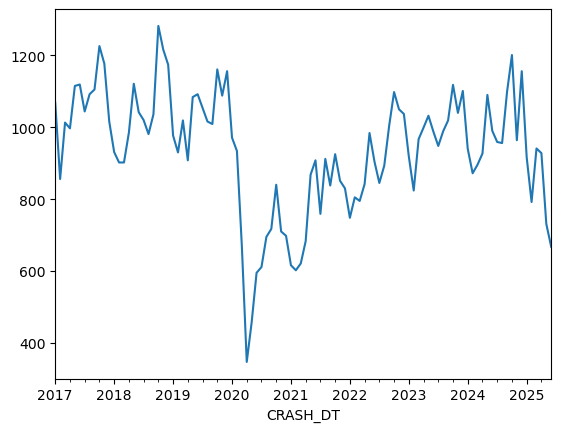

In [55]:
pd.set_option('display.max_rows', None)

df['CRASH_YEAR'] = df['CRASH_YEAR'].astype('int32')
df['CRASH_DT'] = pd.to_datetime(df['CRASH_DT'])
df = df[(df['X'] != 0) | (df['Y'] != 0)]
monthly = df.groupby(df['CRASH_DT'].dt.to_period('M')).size()
monthly.plot(kind='line')
#print(monthly)


#
#print(df.groupby(df['CRASH_YEAR']).size())
print(df.isnull().sum())